# 02 - Forecasting Total Sales

Objetivo: prever a receita total mensal (`Total_Sales_USD`) para os proximos 3 meses, criando primeiro baselines simples e depois um modelo de regressao com Machine Learning.

Como a base tem poucos meses historicos, este notebook prioriza um fluxo robusto e auditavel: validacao temporal, baselines, features com lags, comparacao de erro e previsao final trimestral.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titleweight"] = "bold"

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "product_sales_dataset.csv"
DATA_PATH

WindowsPath('C:/Users/vinicius/Documents/Projetos/Product_sales_analysis/data/raw/product_sales_dataset.csv')

## 2. Carga e agregacao mensal

In [2]:
df = pd.read_csv(DATA_PATH)
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Total_Sales_USD"] = pd.to_numeric(df["Total_Sales_USD"], errors="coerce")
df["Quantity_Sold"] = pd.to_numeric(df["Quantity_Sold"], errors="coerce")
df = df.dropna(subset=["Order_Date", "Total_Sales_USD", "Quantity_Sold"])

df.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta


In [3]:
monthly_all = (
    df.set_index("Order_Date")
    .resample("MS")
    .agg(
        total_sales=("Total_Sales_USD", "sum"),
        quantity_sold=("Quantity_Sold", "sum"),
        orders=("Product_ID", "count"),
        avg_ticket=("Total_Sales_USD", "mean"),
        avg_units_per_order=("Quantity_Sold", "mean"),
    )
    .reset_index()
    .rename(columns={"Order_Date": "month"})
)

monthly_all["month_label"] = monthly_all["month"].dt.strftime("%b/%Y")
monthly_all

,month,total_sales,quantity_sold,orders,avg_ticket,avg_units_per_order,month_label
0,2025-01-01,84241,343,59,"1,427.81",5.81,Jan/2025
1,2025-02-01,90810,347,56,"1,621.61",6.20,Feb/2025
2,2025-03-01,84380,322,59,"1,430.17",5.46,Mar/2025
3,2025-04-01,77831,316,51,"1,526.10",6.20,Apr/2025
4,2025-05-01,88174,338,63,"1,399.59",5.37,May/2025
5,2025-06-01,79293,360,63,"1,258.62",5.71,Jun/2025
6,2025-07-01,72214,294,57,"1,266.91",5.16,Jul/2025
7,2025-08-01,101723,397,66,"1,541.26",6.02,Aug/2025
8,2025-09-01,81216,338,66,"1,230.55",5.12,Sep/2025
9,2025-10-01,92946,348,65,"1,429.94",5.35,Oct/2025


## 3. Tratamento de mes incompleto

Para forecasting mensal, um mes parcialmente observado pode induzir o modelo a aprender uma queda artificial. Por isso, por padrao, o notebook remove o ultimo mes caso ele nao esteja fechado na base.

No dataset atual, a ultima data observada deve ser comparada com o fim do respectivo mes. Se a base terminar antes do ultimo dia do mes, consideramos esse mes incompleto para treinamento.

In [4]:
USE_COMPLETE_MONTHS_ONLY = True

max_order_date = df["Order_Date"].max()
last_month_end = max_order_date.to_period("M").to_timestamp("M")
last_month_start = max_order_date.to_period("M").to_timestamp()
last_month_is_complete = max_order_date.normalize() >= last_month_end.normalize()

if USE_COMPLETE_MONTHS_ONLY and not last_month_is_complete:
    monthly = monthly_all[monthly_all["month"] < last_month_start].copy()
else:
    monthly = monthly_all.copy()

metadata = pd.Series({
    "max_order_date": max_order_date.date(),
    "last_month_start": last_month_start.date(),
    "last_month_end": last_month_end.date(),
    "last_month_is_complete": last_month_is_complete,
    "months_available_all": len(monthly_all),
    "months_used_for_modeling": len(monthly),
    "modeling_start_month": monthly["month"].min().date(),
    "modeling_end_month": monthly["month"].max().date(),
})
metadata

max_order_date              2026-05-16
last_month_start            2026-05-01
last_month_end              2026-05-31
last_month_is_complete           False
months_available_all                17
months_used_for_modeling            16
modeling_start_month        2025-01-01
modeling_end_month          2026-04-01
dtype: object

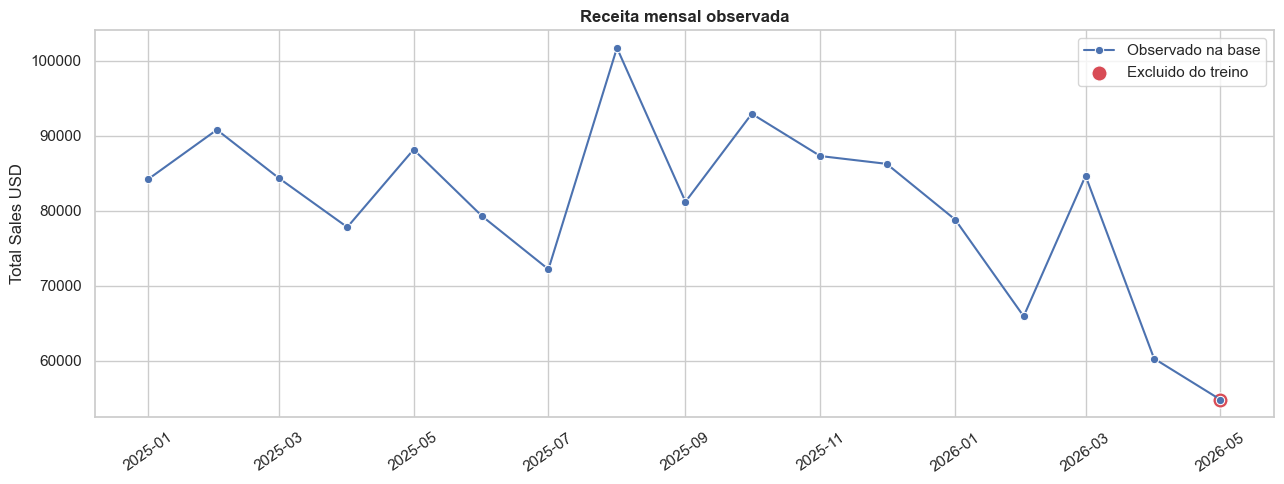

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=monthly_all, x="month", y="total_sales", marker="o", label="Observado na base", ax=ax)
if len(monthly) < len(monthly_all):
    excluded = monthly_all[~monthly_all["month"].isin(monthly["month"])]
    sns.scatterplot(data=excluded, x="month", y="total_sales", s=120, color="#D84B55", label="Excluido do treino", ax=ax)
ax.set_title("Receita mensal observada")
ax.set_xlabel("")
ax.set_ylabel("Total Sales USD")
plt.xticks(rotation=35)
plt.tight_layout()

## 4. Baselines

Baselines sao essenciais porque mostram se o modelo de ML realmente agrega valor. Aqui usaremos:

- **Naive last month**: repete a receita do mes anterior.
- **Moving average 3M**: media dos 3 meses anteriores.
- **Moving average 6M**: media dos 6 meses anteriores.

A avaliacao sera feita no ultimo trimestre disponivel do conjunto de meses completos.

In [6]:
TEST_SIZE = 3

if len(monthly) <= TEST_SIZE + 6:
    print("Aviso: historico curto. A avaliacao sera instavel e deve ser interpretada com cautela.")

train = monthly.iloc[:-TEST_SIZE].copy()
test = monthly.iloc[-TEST_SIZE:].copy()

train[["month", "total_sales"]].tail(), test[["month", "total_sales"]]

(        month  total_sales
 8  2025-09-01        81216
 9  2025-10-01        92946
 10 2025-11-01        87310
 11 2025-12-01        86270
 12 2026-01-01        78844,
         month  total_sales
 13 2026-02-01        65951
 14 2026-03-01        84676
 15 2026-04-01        60312)

In [7]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred),
    }


def recursive_baseline_forecast(history, horizon, method="naive", window=3):
    values = list(history)
    preds = []
    for _ in range(horizon):
        if method == "naive":
            pred = values[-1]
        elif method == "moving_average":
            pred = np.mean(values[-window:])
        else:
            raise ValueError(f"Metodo desconhecido: {method}")
        preds.append(float(pred))
        values.append(float(pred))
    return np.array(preds)


baseline_predictions = {
    "baseline_naive_last_month": recursive_baseline_forecast(train["total_sales"], TEST_SIZE, method="naive"),
    "baseline_moving_avg_3m": recursive_baseline_forecast(train["total_sales"], TEST_SIZE, method="moving_average", window=3),
    "baseline_moving_avg_6m": recursive_baseline_forecast(train["total_sales"], TEST_SIZE, method="moving_average", window=6),
}

baseline_eval = []
for model_name, preds in baseline_predictions.items():
    baseline_eval.append({"model": model_name, **regression_metrics(test["total_sales"], preds)})

baseline_eval = pd.DataFrame(baseline_eval).sort_values("RMSE")
baseline_eval

,model,MAE,RMSE,MAPE_%
0,baseline_naive_last_month,"12,419.00","13,462.00",19.05
1,baseline_moving_avg_3m,"13,830.90","16,378.93",21.82
2,baseline_moving_avg_6m,"16,472.61","19,808.62",26.09


## 4.1. Modelos estatisticos para serie curta

Como temos poucos meses historicos, modelos estatisticos simples podem ser mais adequados do que modelos de arvore. Aqui testamos alternativas de serie temporal:

- **ETS level**: suavizacao exponencial sem tendencia.
- **ARIMA grid search**: busca simples de parametros `(p,d,q)` escolhendo menor AIC no treino.
- **ARIMA drift**: caso especifico de passeio aleatorio com drift, util quando a melhor informacao e o ultimo nivel mais uma direcao media recente.

No `statsmodels`, usamos `SARIMAX` para implementar ARIMA sem componente sazonal, pois ele permite controlar ordem, drift e restricoes numericas.

In [8]:
def fit_forecast_ets(train_series, horizon):
    model = ExponentialSmoothing(
        train_series,
        trend=None,
        seasonal=None,
        initialization_method="estimated",
    ).fit(optimized=True)
    return np.asarray(model.forecast(horizon), dtype=float), model


def fit_forecast_sarimax_drift(train_series, horizon):
    model = SARIMAX(
        train_series,
        order=(0, 1, 0),
        seasonal_order=(0, 0, 0, 0),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)
    return np.asarray(model.forecast(horizon), dtype=float), model


def fit_forecast_arima_grid(train_series, horizon):
    candidate_orders = [
        (0, 0, 0), (1, 0, 0), (0, 0, 1), (1, 0, 1),
        (0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1),
        (2, 1, 0), (0, 1, 2), (2, 1, 1),
    ]
    candidates = []
    for order in candidate_orders:
        d = order[1]
        trend_options = ["c"] if d == 0 else ["n", "c"]
        for trend in trend_options:
            try:
                model = SARIMAX(
                    train_series,
                    order=order,
                    seasonal_order=(0, 0, 0, 0),
                    trend=trend,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False)
                candidates.append({"order": order, "trend": trend, "aic": model.aic, "model": model})
            except Exception:
                continue
    if not candidates:
        raise RuntimeError("Nenhum modelo ARIMA convergiu na grade testada.")
    best_candidate = min(candidates, key=lambda item: item["aic"])
    forecast = np.asarray(best_candidate["model"].forecast(horizon), dtype=float)
    return forecast, best_candidate


train_series = train.set_index("month")["total_sales"].asfreq("MS")
test_series = test.set_index("month")["total_sales"].asfreq("MS")

ts_predictions = {}
ts_models = {}

ts_predictions["ts_exponential_smoothing"], ts_models["ts_exponential_smoothing"] = fit_forecast_ets(train_series, TEST_SIZE)
ts_predictions["ts_arima_grid"], ts_models["ts_arima_grid"] = fit_forecast_arima_grid(train_series, TEST_SIZE)
ts_predictions["ts_sarimax_drift"], ts_models["ts_sarimax_drift"] = fit_forecast_sarimax_drift(train_series, TEST_SIZE)

ts_eval = []
for model_name, preds in ts_predictions.items():
    ts_eval.append({"model": model_name, **regression_metrics(test_series, preds)})

ts_eval = pd.DataFrame(ts_eval).sort_values("RMSE")
print("Melhor ARIMA na grade:", ts_models["ts_arima_grid"]["order"], "trend=", ts_models["ts_arima_grid"]["trend"], "AIC=", round(ts_models["ts_arima_grid"]["aic"], 2))
ts_eval

Melhor ARIMA na grade: (0, 1, 2) trend= n AIC= 192.93


,model,MAE,RMSE,MAPE_%
2,ts_sarimax_drift,"12,119.17","12,850.35",18.44
0,ts_exponential_smoothing,"14,706.38","18,020.13",23.43
1,ts_arima_grid,"14,752.35","18,040.78",23.48


,month,total_sales,baseline_naive_last_month,baseline_moving_avg_3m,baseline_moving_avg_6m,ts_exponential_smoothing,ts_arima_grid,ts_sarimax_drift
13,2026-02-01,65951,"78,844.00","84,141.33","88,051.50","85,019.38","85,844.06","78,394.25"
14,2026-03-01,84676,"78,844.00","83,085.11","85,772.92","85,019.38","84,407.71","77,944.50"
15,2026-04-01,60312,"78,844.00","82,023.48","86,532.40","85,019.38","84,407.71","77,494.75"


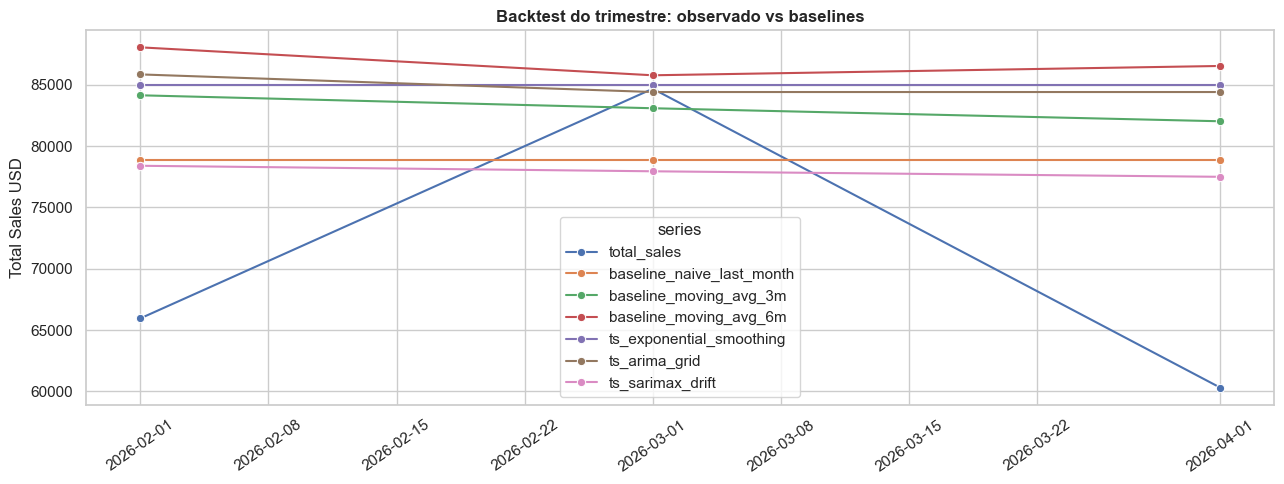

In [9]:
baseline_plot = test[["month", "total_sales"]].copy()
for model_name, preds in baseline_predictions.items():
    baseline_plot[model_name] = preds
for model_name, preds in ts_predictions.items():
    baseline_plot[model_name] = preds

baseline_plot_melted = baseline_plot.melt(id_vars="month", var_name="series", value_name="value")
sns.lineplot(data=baseline_plot_melted, x="month", y="value", hue="series", marker="o")
plt.title("Backtest do trimestre: observado vs baselines")
plt.xlabel("")
plt.ylabel("Total Sales USD")
plt.xticks(rotation=35)
plt.tight_layout()
baseline_plot

## 5. Feature engineering para ML

Como estamos prevendo uma serie mensal agregada, o modelo de ML precisa de features que representem memoria temporal:

- lags de receita;
- medias moveis;
- variacao percentual recente;
- calendario mensal/trimestral.

Com apenas alguns meses de historico, o modelo deve ser interpretado como uma primeira versao experimental, nao como um modelo definitivo de producao.

In [10]:
def add_time_features(data):
    out = data.copy().sort_values("month")
    out["month_num"] = out["month"].dt.month
    out["quarter"] = out["month"].dt.quarter
    out["time_idx"] = np.arange(len(out))
    out["lag_1"] = out["total_sales"].shift(1)
    out["lag_2"] = out["total_sales"].shift(2)
    out["lag_3"] = out["total_sales"].shift(3)
    out["rolling_mean_3"] = out["total_sales"].shift(1).rolling(3).mean()
    out["rolling_std_3"] = out["total_sales"].shift(1).rolling(3).std()
    out["rolling_mean_6"] = out["total_sales"].shift(1).rolling(6).mean()
    out["pct_change_1"] = out["total_sales"].pct_change(1).shift(1)
    out["pct_change_3"] = out["total_sales"].pct_change(3).shift(1)
    return out


feature_cols = [
    "month_num", "quarter", "time_idx",
    "lag_1", "lag_2", "lag_3",
    "rolling_mean_3", "rolling_std_3", "rolling_mean_6",
    "pct_change_1", "pct_change_3",
]

ml_dataset = add_time_features(monthly).dropna().reset_index(drop=True)
ml_dataset[["month", "total_sales"] + feature_cols].head()

,month,total_sales,month_num,quarter,time_idx,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,rolling_mean_6,pct_change_1,pct_change_3
0,2025-07-01,72214,7,3,6,"79,293.00","88,174.00","77,831.00","81,766.00","5,597.43","84,121.50",-0.10,-0.06
1,2025-08-01,101723,8,3,7,"72,214.00","79,293.00","88,174.00","79,893.67","7,996.94","82,117.00",-0.09,-0.07
2,2025-09-01,81216,9,3,8,"101,723.00","72,214.00","79,293.00","84,410.00","15,405.62","83,935.83",0.41,0.15
3,2025-10-01,92946,10,4,9,"81,216.00","101,723.00","72,214.00","85,051.00","15,123.68","83,408.50",-0.20,0.02
4,2025-11-01,87310,11,4,10,"92,946.00","81,216.00","101,723.00","91,961.67","10,288.87","85,927.67",0.14,0.29


In [11]:
ml_train = ml_dataset[ml_dataset["month"].isin(train["month"])].copy()
ml_test = ml_dataset[ml_dataset["month"].isin(test["month"])].copy()

X_train = ml_train[feature_cols]
y_train = ml_train["total_sales"]
X_test = ml_test[feature_cols]
y_test = ml_test["total_sales"]

X_train.shape, X_test.shape

((7, 11), (3, 11))

## 6. Modelo de regressao com ML

In [12]:
ml_models = {
    "ml_gradient_boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=80,
        learning_rate=0.05,
        max_depth=2,
    ),
    "ml_random_forest": RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=2,
    ),
}

ml_predictions = {}
ml_eval = []
for model_name, model in ml_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    ml_predictions[model_name] = preds
    ml_eval.append({"model": model_name, **regression_metrics(y_test, preds)})

ml_eval = pd.DataFrame(ml_eval).sort_values("RMSE")
ml_eval

,model,MAE,RMSE,MAPE_%
1,ml_random_forest,"15,266.50","17,630.63",23.92
0,ml_gradient_boosting,"18,538.97","20,986.76",28.33


In [13]:
all_eval = pd.concat([baseline_eval, ts_eval, ml_eval], ignore_index=True).sort_values("RMSE")
all_eval

,model,MAE,RMSE,MAPE_%
3,ts_sarimax_drift,"12,119.17","12,850.35",18.44
0,baseline_naive_last_month,"12,419.00","13,462.00",19.05
1,baseline_moving_avg_3m,"13,830.90","16,378.93",21.82
6,ml_random_forest,"15,266.50","17,630.63",23.92
4,ts_exponential_smoothing,"14,706.38","18,020.13",23.43
5,ts_arima_grid,"14,752.35","18,040.78",23.48
2,baseline_moving_avg_6m,"16,472.61","19,808.62",26.09
7,ml_gradient_boosting,"18,538.97","20,986.76",28.33


,month,actual,baseline_naive_last_month,baseline_moving_avg_3m,baseline_moving_avg_6m,ts_exponential_smoothing,ts_arima_grid,ts_sarimax_drift,ml_gradient_boosting,ml_random_forest
13,2026-02-01,65951,"78,844.00","84,141.33","88,051.50","85,019.38","85,844.06","78,394.25","77,349.06","82,649.13"
14,2026-03-01,84676,"78,844.00","83,085.11","85,772.92","85,019.38","84,407.71","77,944.50","96,447.08","88,497.18"
15,2026-04-01,60312,"78,844.00","82,023.48","86,532.40","85,019.38","84,407.71","77,494.75","92,759.78","85,592.20"


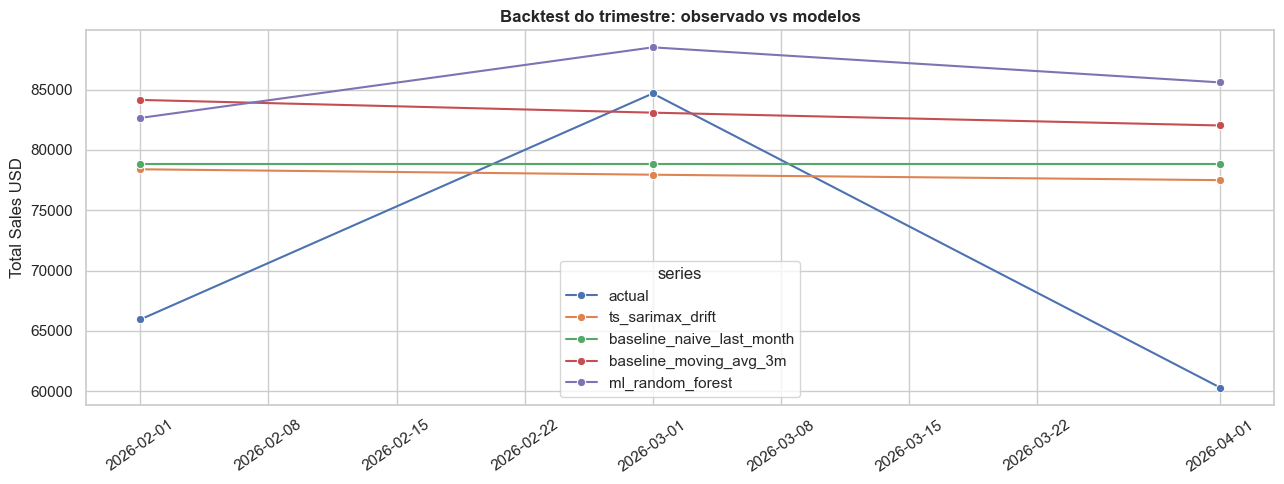

In [14]:
backtest = test[["month", "total_sales"]].copy().rename(columns={"total_sales": "actual"})
for model_name, preds in baseline_predictions.items():
    backtest[model_name] = preds
for model_name, preds in ts_predictions.items():
    backtest[model_name] = preds

for model_name, preds in ml_predictions.items():
    aligned = pd.Series(preds, index=ml_test["month"].values)
    backtest[model_name] = backtest["month"].map(aligned)

top_backtest_series = ["actual"] + all_eval.head(4)["model"].tolist()
backtest_melted = backtest[["month"] + top_backtest_series].melt(id_vars="month", var_name="series", value_name="total_sales")
sns.lineplot(data=backtest_melted, x="month", y="total_sales", hue="series", marker="o")
plt.title("Backtest do trimestre: observado vs modelos")
plt.xlabel("")
plt.ylabel("Total Sales USD")
plt.xticks(rotation=35)
plt.tight_layout()
backtest

## 7. Importancia das features

A importancia de features ajuda a explicar o modelo para analistas. Em series curtas, esses valores devem ser lidos como indicativos, nao como conclusoes definitivas.

,feature,importance
8,rolling_mean_6,0.22
0,month_num,0.19
7,rolling_std_3,0.11
5,lag_3,0.09
10,pct_change_3,0.09
1,quarter,0.08
4,lag_2,0.06
9,pct_change_1,0.06
3,lag_1,0.05
2,time_idx,0.04


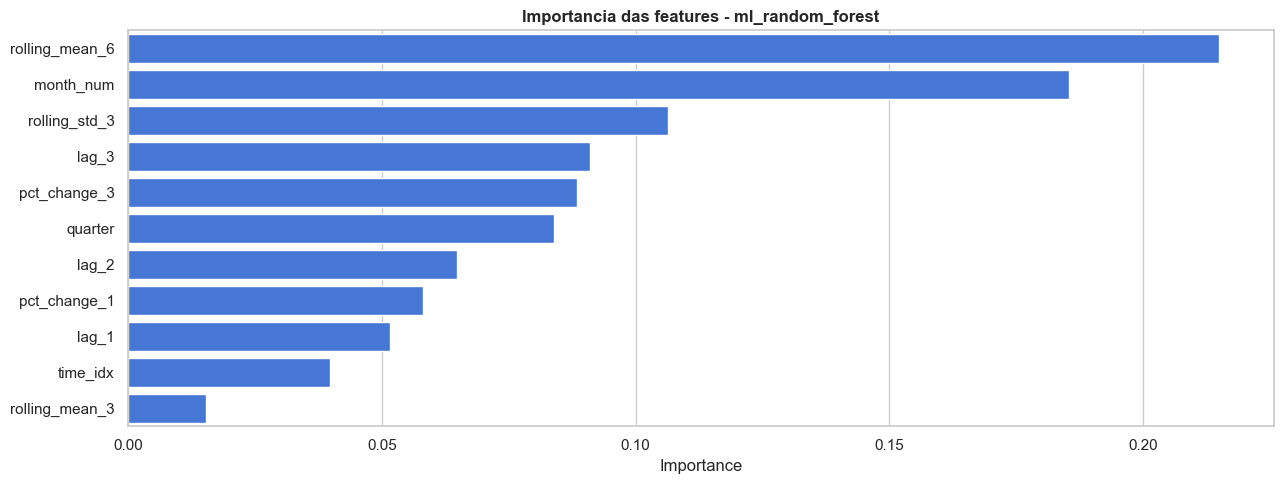

In [15]:
best_ml_name = ml_eval.iloc[0]["model"]
best_ml_model = ml_models[best_ml_name]

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_ml_model.feature_importances_,
}).sort_values("importance", ascending=False)

sns.barplot(data=feature_importance, y="feature", x="importance", color="#2F6FED")
plt.title(f"Importancia das features - {best_ml_name}")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
feature_importance

## 8. Forecast dos proximos 3 meses

Agora treinamos os modelos candidatos em todo o historico usado para modelagem e fazemos a previsao dos proximos 3 meses. O modelo campeao e escolhido pelo menor RMSE no backtest; os demais ficam como referencias de cenario.

Sobre recorrencia do forecast:

- Baselines de media movel e o modelo de ML usam previsao **recursiva explicita**: a previsao do mes 1 entra no historico usado para prever o mes 2, e ambas entram para prever o mes 3.
- ARIMA/ETS usam previsao **multi-step interna** do proprio modelo: `forecast(3)` propaga o estado previsto do modelo para os passos seguintes. Na pratica, isso tambem evita usar valores reais futuros que nao estariam disponiveis.

Como o ultimo mes observado na base pode estar incompleto, o horizonte e calculado a partir do ultimo mes usado no treino.

In [16]:
def build_next_feature_row(history, next_month):
    values = history["total_sales"].tolist()
    row = {
        "month_num": next_month.month,
        "quarter": next_month.quarter,
        "time_idx": len(history),
        "lag_1": values[-1],
        "lag_2": values[-2],
        "lag_3": values[-3],
        "rolling_mean_3": np.mean(values[-3:]),
        "rolling_std_3": np.std(values[-3:], ddof=1),
        "rolling_mean_6": np.mean(values[-6:]),
        "pct_change_1": (values[-1] / values[-2]) - 1 if values[-2] != 0 else 0,
        "pct_change_3": (values[-1] / values[-4]) - 1 if len(values) >= 4 and values[-4] != 0 else 0,
    }
    return pd.DataFrame([row])[feature_cols]


def recursive_ml_forecast(model, history, horizon=3):
    history = history[["month", "total_sales"]].copy().sort_values("month")
    preds = []
    for step in range(1, horizon + 1):
        next_month = history["month"].max() + pd.DateOffset(months=1)
        X_next = build_next_feature_row(history, next_month)
        pred = float(model.predict(X_next)[0])
        pred = max(pred, 0)
        preds.append({"month": next_month, "forecast_total_sales": pred})
        history = pd.concat([
            history,
            pd.DataFrame({"month": [next_month], "total_sales": [pred]}),
        ], ignore_index=True)
    return pd.DataFrame(preds)


final_ml_dataset = add_time_features(monthly).dropna().reset_index(drop=True)
final_model = ml_models[best_ml_name]
final_model.fit(final_ml_dataset[feature_cols], final_ml_dataset["total_sales"])

ml_forecast = recursive_ml_forecast(final_model, monthly, horizon=3)
ml_forecast["model"] = best_ml_name
ml_forecast["forecast_strategy"] = "recursive_explicit"

best_baseline_name = baseline_eval.iloc[0]["model"]
if best_baseline_name == "baseline_naive_last_month":
    baseline_future = recursive_baseline_forecast(monthly["total_sales"], 3, method="naive")
elif best_baseline_name == "baseline_moving_avg_3m":
    baseline_future = recursive_baseline_forecast(monthly["total_sales"], 3, method="moving_average", window=3)
else:
    baseline_future = recursive_baseline_forecast(monthly["total_sales"], 3, method="moving_average", window=6)

future_months = pd.date_range(monthly["month"].max() + pd.DateOffset(months=1), periods=3, freq="MS")
baseline_forecast = pd.DataFrame({
    "month": future_months,
    "forecast_total_sales": baseline_future,
    "model": best_baseline_name,
    "forecast_strategy": "recursive_explicit",
})

full_series = monthly.set_index("month")["total_sales"].asfreq("MS")
ts_future_frames = []
for model_name in ts_eval["model"]:
    if model_name == "ts_exponential_smoothing":
        future_values, _ = fit_forecast_ets(full_series, 3)
    elif model_name == "ts_arima_grid":
        future_values, _ = fit_forecast_arima_grid(full_series, 3)
    elif model_name == "ts_sarimax_drift":
        future_values, _ = fit_forecast_sarimax_drift(full_series, 3)
    else:
        continue
    ts_future_frames.append(pd.DataFrame({
        "month": future_months,
        "forecast_total_sales": np.maximum(future_values, 0),
        "model": model_name,
        "forecast_strategy": "internal_multi_step",
    }))

candidate_forecasts = [baseline_forecast, *ts_future_frames, ml_forecast]
forecast_comparison = pd.concat(candidate_forecasts, ignore_index=True)
champion_model = all_eval.iloc[0]["model"]
forecast_comparison["selected"] = np.where(forecast_comparison["model"] == champion_model, "champion", "reference")
forecast_comparison["horizon"] = forecast_comparison.groupby("model").cumcount() + 1
forecast_comparison["horizon_label"] = "M+" + forecast_comparison["horizon"].astype(str)
forecast_comparison["month_label"] = forecast_comparison["month"].dt.strftime("%b/%Y")
forecast_comparison["forecast_total_sales_fmt"] = forecast_comparison["forecast_total_sales"].map(lambda x: f"${x:,.0f}")
forecast_comparison

,month,forecast_total_sales,model,forecast_strategy,selected,horizon,horizon_label,month_label,forecast_total_sales_fmt
0,2026-05-01,"60,312.00",baseline_naive_last_month,recursive_explicit,reference,1,M+1,May/2026,"$60,312"
1,2026-06-01,"60,312.00",baseline_naive_last_month,recursive_explicit,reference,2,M+2,Jun/2026,"$60,312"
2,2026-07-01,"60,312.00",baseline_naive_last_month,recursive_explicit,reference,3,M+3,Jul/2026,"$60,312"
3,2026-05-01,"58,716.73",ts_sarimax_drift,internal_multi_step,champion,1,M+1,May/2026,"$58,717"
4,2026-06-01,"57,121.47",ts_sarimax_drift,internal_multi_step,champion,2,M+2,Jun/2026,"$57,121"
5,2026-07-01,"55,526.20",ts_sarimax_drift,internal_multi_step,champion,3,M+3,Jul/2026,"$55,526"
6,2026-05-01,"82,262.37",ts_exponential_smoothing,internal_multi_step,reference,1,M+1,May/2026,"$82,262"
7,2026-06-01,"82,262.37",ts_exponential_smoothing,internal_multi_step,reference,2,M+2,Jun/2026,"$82,262"
8,2026-07-01,"82,262.37",ts_exponential_smoothing,internal_multi_step,reference,3,M+3,Jul/2026,"$82,262"
9,2026-05-01,"70,450.78",ts_arima_grid,internal_multi_step,reference,1,M+1,May/2026,"$70,451"


In [17]:
forecast_timeline = pd.Series({
    "ultimo_mes_completo_usado_no_treino": monthly["month"].max().strftime("%b/%Y"),
    "primeiro_mes_previsto_M+1": forecast_comparison["month"].min().strftime("%b/%Y"),
    "ultimo_mes_previsto_M+3": forecast_comparison["month"].max().strftime("%b/%Y"),
    "mes_incompleto_removido_do_treino": last_month_start.strftime("%b/%Y") if USE_COMPLETE_MONTHS_ONLY and not last_month_is_complete else "nenhum",
})
forecast_timeline

ultimo_mes_completo_usado_no_treino    Apr/2026
primeiro_mes_previsto_M+1              May/2026
ultimo_mes_previsto_M+3                Jul/2026
mes_incompleto_removido_do_treino      May/2026
dtype: object

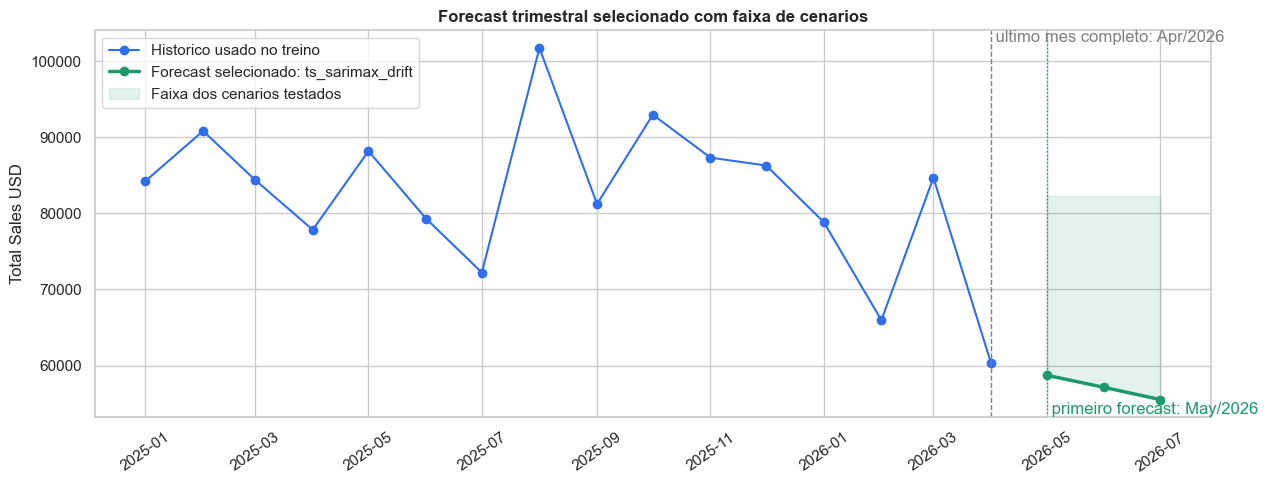

In [18]:
history_plot = monthly[["month", "total_sales"]].copy().rename(columns={"total_sales": "value"})
champion_forecast = forecast_comparison[forecast_comparison["model"] == champion_model].copy()
last_train_month = monthly["month"].max()
first_forecast_month = champion_forecast["month"].min()
scenario_band = (
    forecast_comparison.groupby("month", as_index=False)
    .agg(
        scenario_min=("forecast_total_sales", "min"),
        scenario_max=("forecast_total_sales", "max"),
    )
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(history_plot["month"], history_plot["value"], marker="o", color="#2F6FED", label="Historico usado no treino")
ax.plot(
    champion_forecast["month"],
    champion_forecast["forecast_total_sales"],
    marker="o",
    color="#1D9A6C",
    linewidth=2.5,
    label=f"Forecast selecionado: {champion_model}",
)
ax.fill_between(
    scenario_band["month"],
    scenario_band["scenario_min"],
    scenario_band["scenario_max"],
    color="#1D9A6C",
    alpha=0.12,
    label="Faixa dos cenarios testados",
)
ax.axvline(last_train_month, color="gray", linestyle="--", linewidth=1)
ax.axvline(first_forecast_month, color="#1D9A6C", linestyle=":", linewidth=1)
ax.text(last_train_month, ax.get_ylim()[1], f" ultimo mes completo: {last_train_month:%b/%Y}", va="top", ha="left", color="gray")
ax.text(first_forecast_month, ax.get_ylim()[0], f" primeiro forecast: {first_forecast_month:%b/%Y}", va="bottom", ha="left", color="#1D9A6C")
ax.set_title("Forecast trimestral selecionado com faixa de cenarios")
ax.set_xlabel("")
ax.set_ylabel("Total Sales USD")
ax.legend(loc="best")
plt.xticks(rotation=35)
plt.tight_layout()

## 9. Resultado trimestral esperado

In [19]:
quarter_forecast = (
    forecast_comparison.groupby("model", as_index=False)
    .agg(
        forecast_3_month_total=("forecast_total_sales", "sum"),
        forecast_monthly_avg=("forecast_total_sales", "mean"),
        min_month_forecast=("forecast_total_sales", "min"),
        max_month_forecast=("forecast_total_sales", "max"),
    )
)

for col in ["forecast_3_month_total", "forecast_monthly_avg", "min_month_forecast", "max_month_forecast"]:
    quarter_forecast[col + "_fmt"] = quarter_forecast[col].map(lambda x: f"${x:,.0f}")

quarter_forecast

,model,forecast_3_month_total,forecast_monthly_avg,min_month_forecast,max_month_forecast,forecast_3_month_total_fmt,forecast_monthly_avg_fmt,min_month_forecast_fmt,max_month_forecast_fmt
0,baseline_naive_last_month,"180,936.00","60,312.00","60,312.00","60,312.00","$180,936","$60,312","$60,312","$60,312"
1,ml_random_forest,"232,795.97","77,598.66","76,861.26","78,545.19","$232,796","$77,599","$76,861","$78,545"
2,ts_arima_grid,"202,742.47","67,580.82","66,145.84","70,450.78","$202,742","$67,581","$66,146","$70,451"
3,ts_exponential_smoothing,"246,787.11","82,262.37","82,262.37","82,262.37","$246,787","$82,262","$82,262","$82,262"
4,ts_sarimax_drift,"171,364.40","57,121.47","55,526.20","58,716.73","$171,364","$57,121","$55,526","$58,717"


## 10. Conclusoes e proximos passos

- A base mensal ainda e curta para um modelo de forecasting definitivo. A comparacao com baseline e obrigatoria para evitar falsa sofisticacao.
- O ultimo mes incompleto foi removido por padrao para reduzir viés de queda artificial.
- O modelo de ML usa lags e estatisticas moveis para prever a receita mensal total.
- Para producao, o ideal e acumular mais meses ou usar granularidade diaria/semanal, se a operacao tiver volume suficiente.
- O proximo passo natural e repetir a abordagem para `Quantity_Sold`, depois por categoria/produto, com conciliacao hierarquica dos forecasts.